# VES Inversion Using Grid Search and PSO
Notebook bergaya course notebook dengan alur: model → data sintetik → noise → misfit → Grid Search → PSO → evaluasi hasil.

In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


## 1. Model Bumi Sintetik

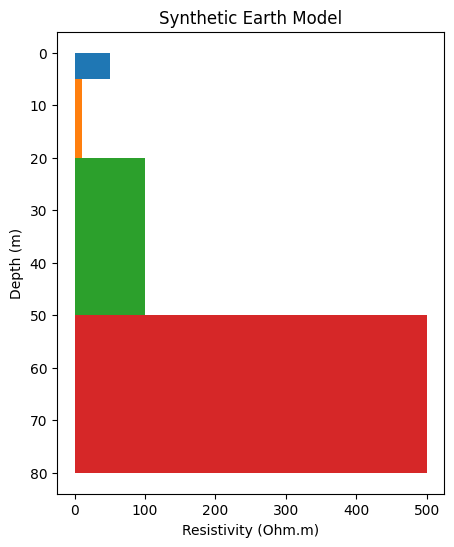

In [2]:

rho_true = np.array([50, 10, 100, 500])   # Ohm.m
h_true = np.array([5, 15, 30])            # m

depth = np.r_[0, np.cumsum(h_true), 80]

plt.figure(figsize=(5,6))
for i in range(len(rho_true)):
    plt.fill_betweenx([depth[i], depth[i+1]], 0, rho_true[i])
plt.gca().invert_yaxis()
plt.xlabel("Resistivity (Ohm.m)")
plt.ylabel("Depth (m)")
plt.title("Synthetic Earth Model")
plt.show()


## 2. Forward Model Sederhana

In [3]:

def forward_ves(model, ab2):
    rho1, rho2, rho3, h1, h2 = model

    term1 = rho1*np.exp(-ab2/(h1+1))
    term2 = rho2*(1-np.exp(-ab2/(h1+1)))*np.exp(-ab2/(h2+1))
    term3 = rho3*(1-np.exp(-ab2/(h2+1)))

    return term1 + term2 + term3


## 3. Generate Data Sintetik

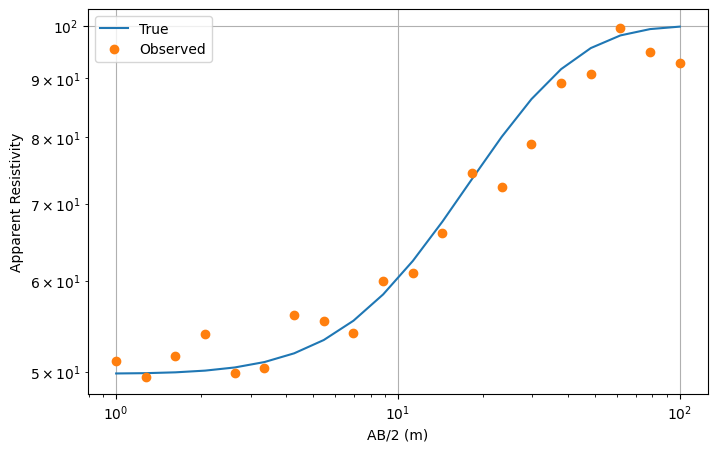

In [4]:

ab2 = np.logspace(0,2,20)

true_model = [50,10,100,5,15]

rho_clean = forward_ves(true_model, ab2)

noise = np.random.normal(0,0.05*rho_clean)
rho_obs = rho_clean + noise

plt.figure(figsize=(8,5))
plt.loglog(ab2,rho_clean,label='True')
plt.loglog(ab2,rho_obs,'o',label='Observed')
plt.xlabel('AB/2 (m)')
plt.ylabel('Apparent Resistivity')
plt.legend()
plt.grid(True)
plt.show()


## 4. Fungsi Misfit

In [5]:

sigma = 0.05*rho_obs

def misfit(model):
    rho_calc = forward_ves(model, ab2)
    return np.sum(((rho_obs-rho_calc)/sigma)**2)


## 5. Grid Search

In [6]:

rho1_range = np.linspace(20,80,20)
rho2_range = np.linspace(5,30,20)
rho3_range = np.linspace(50,150,20)

best_misfit = np.inf
best_grid_model = None

misfit_surface = np.zeros((len(rho2_range),len(rho3_range)))

for i,r2 in enumerate(rho2_range):
    for j,r3 in enumerate(rho3_range):

        m = [50,r2,r3,5,15]

        E = misfit(m)

        misfit_surface[i,j] = E

        if E < best_misfit:
            best_misfit = E
            best_grid_model = m

print("Best Grid Model")
print(best_grid_model)
print("Misfit =", best_misfit)


Best Grid Model
[50, np.float64(18.157894736842106), np.float64(92.10526315789474), 5, 15]
Misfit = 11.48601735551921


## 6. Visualisasi Misfit Surface

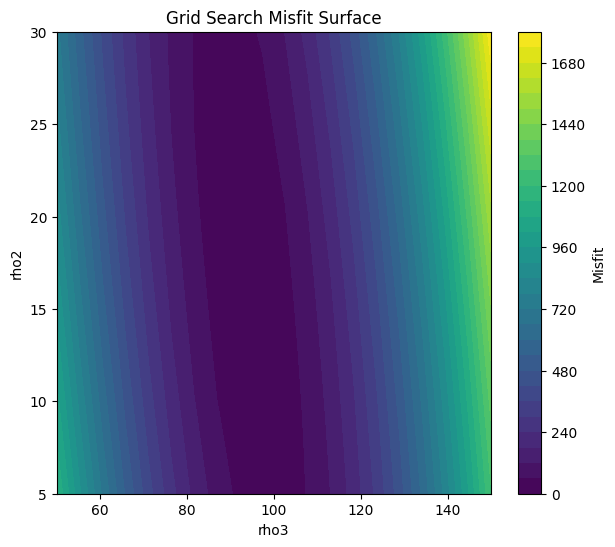

In [7]:

R2,R3 = np.meshgrid(rho3_range,rho2_range)

plt.figure(figsize=(7,6))
plt.contourf(R2,R3,misfit_surface,30)
plt.colorbar(label='Misfit')
plt.xlabel('rho3')
plt.ylabel('rho2')
plt.title('Grid Search Misfit Surface')
plt.show()


## 7. Particle Swarm Optimization (PSO)

In [8]:

n_particles = 30
n_iter = 100

bounds = np.array([
    [20,80],
    [5,30],
    [50,150],
    [2,10],
    [5,30]
])

dim = len(bounds)

pos = np.random.uniform(bounds[:,0],bounds[:,1],(n_particles,dim))
vel = np.zeros((n_particles,dim))

pbest = pos.copy()
pbest_val = np.array([misfit(p) for p in pos])

gbest_idx = np.argmin(pbest_val)
gbest = pbest[gbest_idx].copy()
gbest_val = pbest_val[gbest_idx]

history = []

w = 0.7
c1 = 2.0
c2 = 2.0

for _ in range(n_iter):

    r1 = np.random.rand(n_particles,dim)
    r2 = np.random.rand(n_particles,dim)

    vel = (
        w*vel +
        c1*r1*(pbest-pos) +
        c2*r2*(gbest-pos)
    )

    pos += vel

    pos = np.clip(pos,bounds[:,0],bounds[:,1])

    vals = np.array([misfit(p) for p in pos])

    mask = vals < pbest_val
    pbest[mask] = pos[mask]
    pbest_val[mask] = vals[mask]

    idx = np.argmin(pbest_val)

    if pbest_val[idx] < gbest_val:
        gbest = pbest[idx].copy()
        gbest_val = pbest_val[idx]

    history.append(gbest_val)

print("Best PSO Model")
print(gbest)
print("Misfit =", gbest_val)


Best PSO Model
[50.23447177 11.73992219 96.31743323  6.67867442 16.78642669]
Misfit = 9.193235979460928


## 8. Kurva Konvergensi PSO

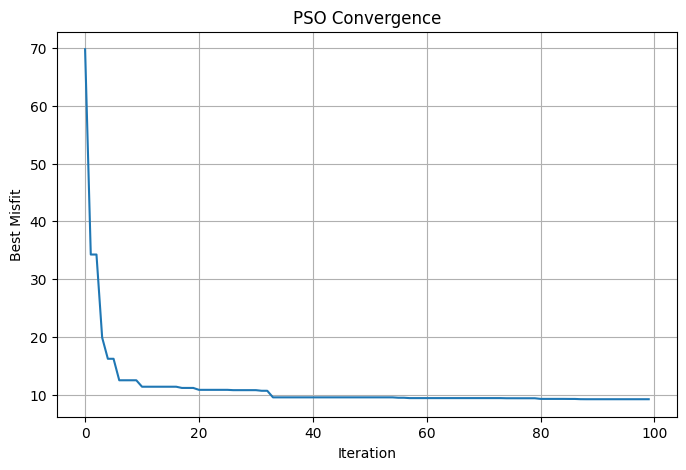

In [9]:

plt.figure(figsize=(8,5))
plt.plot(history)
plt.xlabel('Iteration')
plt.ylabel('Best Misfit')
plt.title('PSO Convergence')
plt.grid()
plt.show()


## 9. Perbandingan Hasil

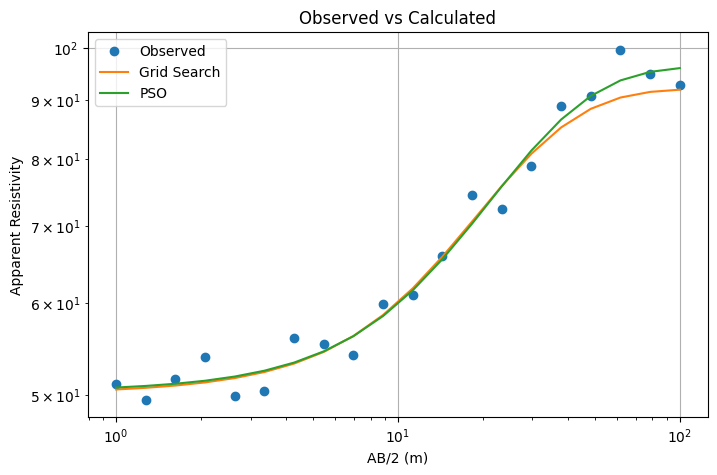

In [10]:

rho_grid = forward_ves(best_grid_model,ab2)
rho_pso = forward_ves(gbest,ab2)

plt.figure(figsize=(8,5))

plt.loglog(ab2,rho_obs,'o',label='Observed')
plt.loglog(ab2,rho_grid,label='Grid Search')
plt.loglog(ab2,rho_pso,label='PSO')

plt.xlabel('AB/2 (m)')
plt.ylabel('Apparent Resistivity')
plt.title('Observed vs Calculated')
plt.legend()
plt.grid()
plt.show()
